# CISC7204 Project: Cambridgeshire Road Collision Patterns - Verification Notebook

**Authors:** Chan Ka Wai (MC649337), Liu Haixiang (MC649298)

**Course:** CISC7204 Data Science and Data Visualization, University of Macau

Optional Python 3 deliverable of the project proposal. It rebuilds the tables and figures from the
published files and records the audit and cleaning decisions of Tasks 1 to 6.

Raw files are in `data/raw`. A file is downloaded only when it is missing. No value is simulated.

| Dataset | Catalogue page |
| --- | --- |
| Dataset 1: Casualties by Mode of Transport Counts | https://www.data.gov.uk/dataset/3e01b839-fc7b-4d77-b5b0-6e86528117a1/cambridgeshire-road-traffic-collision-casualties-by-mode-of-transport-counts1 |
| Dataset 2: Road Traffic Collisions: Location | https://www.data.gov.uk/dataset/b063ff63-7d19-4c9d-a817-26a64dfdce57/road-traffic-collisions-location1 |

In [1]:
%matplotlib inline
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
plt.rcParams['figure.figsize'] = (12, 5)
SEVERITY_ORDER = ['Fatal', 'Serious', 'Slight']
SEVERITY_COLOURS = {'Slight': '#4c78a8', 'Serious': '#e08b2f', 'Fatal': '#8c2d2d'}
STATE_ORDER = ['5 or more', '1 to 4', '0', '<5', '-1', 'blank']
STATE_COLOURS = {'5 or more': '#1f4e79', '1 to 4': '#7ba7d1', '0': '#f0f0f0', '<5': '#e8a33d', '-1': '#b04a4a', 'blank': '#cfcfcf'}

## Step 1. Source log and raw file inventory (Task 1)

In [2]:
RAW = 'data/raw'
CLEAN = 'data/clean'
FIG = 'figures'
for folder in [RAW, CLEAN, FIG]:
    os.makedirs(folder, exist_ok=True)
LOCATION_FILES = {
    2012: ('RTC_Location_2012.xlsx', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/RTC%20Location%202012.xlsx'),
    2013: ('RTC_Location_2013.xlsx', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/RTC%20Location%202013.xlsx'),
    2014: ('RTC_Location_2014.xlsx', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/RTC%20Location%202014.xlsx'),
    2015: ('RTC_Location_2015.xlsx', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/RTC%20Location%202015.xlsx'),
    2016: ('RTC_Location_2016.xlsx', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/RTC%20Location%202016.xlsx'),
    2017: ('RTC_Location_2017.xlsx', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/RTC%20Location%202017_0.xlsx'),
    2018: ('RTC_Location_2018.csv', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/RTC%20Location%202018.csv'),
}
MODE_FILES = {
    'Cambridgeshire': ('Mode_Cambridgeshire.csv', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/Cambridgeshire%20monthly%20road%20traffic%20casualties%20by%20transport%20mode%202012%20to%202017.csv'),
    'Cambridge City': ('Mode_Cambridge_City.csv', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/Cambridge%20City%20district%20monthly%20road%20traffic%20casualties%20by%20transport%20mode%202012%20to%202017.csv'),
    'East Cambridgeshire': ('Mode_East_Cambridgeshire.csv', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/East%20Cambridgeshire%20district%20monthly%20road%20traffic%20casualties%20by%20transport%20mode%202012%20to%202017.csv'),
    'Fenland': ('Mode_Fenland.csv', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/Fenland%20district%20monthly%20road%20traffic%20casualties%20by%20transport%20mode%202012%20to%202017.csv'),
    'Huntingdonshire': ('Mode_Huntingdonshire.csv', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/Huntingdonshire%20district%20monthly%20road%20traffic%20casualties%20by%20transport%20mode%202012%20to%202017.csv'),
    'South Cambridgeshire': ('Mode_South_Cambridgeshire.csv', 'https://data.cambridgeshireinsight.org.uk/sites/default/files/South%20Cambridgeshire%20district%20monthly%20road%20traffic%20casualties%20by%20transport%20mode%202012%20to%202017.csv'),
}
def get_file(name, url):
    path = RAW + '/' + name
    if os.path.exists(path):
        return path
    try:
        urllib.request.urlretrieve(url, path)
    except Exception:
        print('cannot download ' + name + ' - put the file in ' + RAW + ' and run again')
        raise
    return path

for year in LOCATION_FILES:
    name, url = LOCATION_FILES[year]
    get_file(name, url)
for area in MODE_FILES:
    name, url = MODE_FILES[area]
    get_file(name, url)
rows = []
for year in LOCATION_FILES:
    name, url = LOCATION_FILES[year]
    rows.append({'dataset': 'Dataset 2: collisions location', 'area_or_year': year, 'file_name': name,
                 'format': name.split('.')[-1].upper(), 'size_kb': round(os.path.getsize(RAW + '/' + name) / 1024, 1),
                 'source_url': url})
for area in MODE_FILES:
    name, url = MODE_FILES[area]
    rows.append({'dataset': 'Dataset 1: casualties by mode of transport', 'area_or_year': area, 'file_name': name,
                 'format': name.split('.')[-1].upper(), 'size_kb': round(os.path.getsize(RAW + '/' + name) / 1024, 1),
                 'source_url': url})
source_log = pd.DataFrame(rows)
source_log.to_csv(CLEAN + '/source_log.csv', index=False)
source_log[['dataset', 'area_or_year', 'file_name', 'format', 'size_kb']]

,dataset,area_or_year,file_name,format,size_kb
0,Dataset 2: collisions location,2012,RTC_Location_2012.xlsx,XLSX,528.3
1,Dataset 2: collisions location,2013,RTC_Location_2013.xlsx,XLSX,474.5
2,Dataset 2: collisions location,2014,RTC_Location_2014.xlsx,XLSX,471.6
3,Dataset 2: collisions location,2015,RTC_Location_2015.xlsx,XLSX,453.0
4,Dataset 2: collisions location,2016,RTC_Location_2016.xlsx,XLSX,488.9
5,Dataset 2: collisions location,2017,RTC_Location_2017.xlsx,XLSX,254.3
6,Dataset 2: collisions location,2018,RTC_Location_2018.csv,CSV,673.6
7,Dataset 1: casualties by mode of transport,Cambridgeshire,Mode_Cambridgeshire.csv,CSV,1.9
8,Dataset 1: casualties by mode of transport,Cambridge City,Mode_Cambridge_City.csv,CSV,1.7
9,Dataset 1: casualties by mode of transport,East Cambridgeshire,Mode_East_Cambridgeshire.csv,CSV,1.7


## Step 2. Data audit (Task 2)

In [3]:
def read_location(year):
    name = LOCATION_FILES[year][0]
    if name.endswith('.csv'):
        return pd.read_csv(RAW + '/' + name, low_memory=False)
    return pd.read_excel(RAW + '/' + name)

rows = []
for year in LOCATION_FILES:
    data = read_location(year)
    dates = pd.to_datetime(data['Date'].astype(str), format='%Y%m%d')
    modern = 'Local_Auth' in data.columns
    rows.append({'year': year, 'collisions': len(data), 'columns': data.shape[1],
                 'first_date': dates.min().date(), 'last_date': dates.max().date(),
                 'months': dates.dt.strftime('%Y-%m').nunique(), 'bad_dates': dates.isna().sum(),
                 'severity_labels': ' / '.join(sorted(data['Severity'].unique())),
                 'surface_column': 'Road_cond' if modern else 'Surface',
                 'has_district': modern, 'has_casualties': 'Casualties' in data.columns})
coverage_location = pd.DataFrame(rows)
coverage_location.to_csv(CLEAN + '/coverage_audit_collision_location.csv', index=False)
coverage_location

,year,collisions,columns,first_date,last_date,months,bad_dates,severity_labels,surface_column,has_district,has_casualties
0,2012,2319,54,2012-01-01,2012-12-31,12,0,Fatal / Serious / Slight,Surface,False,False
1,2013,2067,54,2013-01-01,2013-12-31,12,0,Fatal / Serious / Slight,Surface,False,False
2,2014,2048,54,2014-01-01,2014-12-31,12,0,Fatal / Serious / Slight,Surface,False,False
3,2015,1968,54,2015-01-01,2015-12-31,12,0,Fatal / Serious / Slight,Surface,False,False
4,2016,2125,54,2016-01-01,2016-12-31,12,0,Fatal / Serious / Slight,Surface,False,False
5,2017,1427,36,2017-01-01,2017-12-30,12,0,1. Fatal / 2. Serious / 3. Slight,Road_cond,True,True
6,2018,1802,34,2018-01-01,2018-12-31,12,0,1. Fatal / 2. Serious / 3. Slight,Road_cond,True,True


In [4]:
for year in LOCATION_FILES:
    data = read_location(year)
    if 'Local_Auth' in data.columns:
        print(year, len(data['Local_Auth'].unique()), sorted(data['Local_Auth'].unique()))
    else:
        print(year, 'no local authority field')

2012 no local authority field


2013 no local authority field


2014 no local authority field


2015 no local authority field


2016 no local authority field


2017 5 ['E07000008', 'E07000009', 'E07000010', 'E07000011', 'E07000012']
2018 6 ['E06000031', 'E07000008', 'E07000009', 'E07000010', 'E07000011', 'E07000012']


In [5]:
def read_mode(area):
    data = pd.read_csv(RAW + '/' + MODE_FILES[area][0])
    return data.rename(columns={data.columns[0]: 'Mode'})

def state(value):
    text = str(value).strip()
    if text == '' or text.lower() == 'nan':
        return 'blank'
    if text == '<5':
        return '<5'
    if text == '-1':
        return '-1'
    if int(text) == 0:
        return '0'
    if int(text) >= 5:
        return '5 or more'
    return '1 to 4'

mode_data = {}
for area in MODE_FILES:
    mode_data[area] = read_mode(area)
months = list(mode_data['Cambridgeshire'].columns[1:])
rows = []
for area in mode_data:
    states = [state(value) for value in mode_data[area][months].values.flatten()]
    counts = pd.Series(states).value_counts()
    rows.append({'area': area, 'modes': ', '.join(mode_data[area]['Mode']), 'months': len(months),
                 'cells': len(states), '5 or more': counts.get('5 or more', 0), '1 to 4': counts.get('1 to 4', 0),
                 '0': counts.get('0', 0), '<5': counts.get('<5', 0), '-1': counts.get('-1', 0),
                 'blank': counts.get('blank', 0)})
coverage_mode = pd.DataFrame(rows)
coverage_mode.to_csv(CLEAN + '/coverage_audit_transport_mode.csv', index=False)
coverage_mode

,area,modes,months,cells,5 or more,1 to 4,0,<5,-1,blank
0,Cambridgeshire,"Pedestrians, Cyclists, Motor cyclists, Car occ...",68,408,405,0,0,3,0,0
1,Cambridge City,"Pedestrians, Cyclists, Motor cyclists, Car occ...",68,408,272,0,1,133,0,2
2,East Cambridgeshire,"Pedestrians, Cyclists, Motor cyclists, Car occ...",68,408,165,0,59,183,1,0
3,Fenland,"Pedestrians, Cyclists, Motor cyclists, Car occ...",68,408,184,0,24,200,0,0
4,Huntingdonshire,"Pedestrians, Cyclists, Motor cyclists, Car occ...",68,408,258,0,12,138,0,0
5,South Cambridgeshire,"Pedestrians, Cyclists, Motor cyclists, Car occ...",68,408,256,0,14,138,0,0


In [6]:
dictionary_rows = [
    {'field': 'Date', 'meaning': 'date of the recorded collision', 'published_as': 'YYYYMMDD',
     'in_2012_2016': 'yes', 'in_2017_2018': 'yes'},
    {'field': 'Severity', 'meaning': 'Fatal, Serious or Slight', 'published_as': 'label',
     'in_2012_2016': 'Slight / Serious / Fatal', 'in_2017_2018': '3. Slight / 2. Serious / 1. Fatal'},
    {'field': 'Surface or Road_cond', 'meaning': 'road surface at the time of the collision', 'published_as': 'label',
     'in_2012_2016': '6 labels, including Flood >3cm', 'in_2017_2018': '4 numbered labels'},
    {'field': 'Weather', 'meaning': 'weather at the time of the collision', 'published_as': 'label',
     'in_2012_2016': '9 labels, including Uncoded', 'in_2017_2018': '9 numbered labels'},
    {'field': 'Local_Auth', 'meaning': 'area where the collision was recorded', 'published_as': 'ONS code',
     'in_2012_2016': 'not published', 'in_2017_2018': 'yes'},
    {'field': 'Casualties', 'meaning': 'number of casualties in the collision', 'published_as': 'integer',
     'in_2012_2016': 'not published', 'in_2017_2018': 'yes'},
    {'field': 'Easting / Northing', 'meaning': 'published location of the collision', 'published_as': 'metres',
     'in_2012_2016': 'yes', 'in_2017_2018': 'yes'},
    {'field': 'Mode', 'meaning': 'casualty mode of transport in Dataset 1', 'published_as': 'row label',
     'in_2012_2016': 'yes', 'in_2017_2018': 'yes, up to August 2017'},
    {'field': 'month columns', 'meaning': 'monthly casualty counts in Dataset 1, values under five suppressed',
     'published_as': 'count, <5 or 0', 'in_2012_2016': 'yes', 'in_2017_2018': 'yes, up to August 2017'}]
data_dictionary = pd.DataFrame(dictionary_rows)
data_dictionary.to_csv(CLEAN + '/data_dictionary.csv', index=False)
data_dictionary

,field,meaning,published_as,in_2012_2016,in_2017_2018
0,Date,date of the recorded collision,YYYYMMDD,yes,yes
1,Severity,"Fatal, Serious or Slight",label,Slight / Serious / Fatal,3. Slight / 2. Serious / 1. Fatal
2,Surface or Road_cond,road surface at the time of the collision,label,"6 labels, including Flood >3cm",4 numbered labels
3,Weather,weather at the time of the collision,label,"9 labels, including Uncoded",9 numbered labels
4,Local_Auth,area where the collision was recorded,ONS code,not published,yes
5,Casualties,number of casualties in the collision,integer,not published,yes
6,Easting / Northing,published location of the collision,metres,yes,yes
7,Mode,casualty mode of transport in Dataset 1,row label,yes,"yes, up to August 2017"
8,month columns,"monthly casualty counts in Dataset 1, values u...","count, <5 or 0",yes,"yes, up to August 2017"


## Step 3. Cleaning and harmonisation (Task 3)

In [7]:
SEVERITY_REPLACE = {'Slight': 'Slight', 'Serious': 'Serious', 'Fatal': 'Fatal',
                    '3. Slight': 'Slight', '2. Serious': 'Serious', '1. Fatal': 'Fatal'}
SURFACE_REPLACE = {'Dry': 'Dry', '1. Dry': 'Dry', 'Wet/damp': 'Wet or damp', '2. Wet/Damp': 'Wet or damp',
                   'Snow': 'Snow', '3. Snow': 'Snow', 'Frost/Ice': 'Frost or ice', '4. Frost/Ice': 'Frost or ice',
                   'Flood >3cm': 'Flood (over 3cm)', 'Unknown': 'Unknown or not stated'}
WEATHER_REPLACE = {'Fine (no wind)': 'Fine without high winds', '1. Fine without high winds': 'Fine without high winds',
                   'Fine & windy': 'Fine with high winds', '4. Fine with high winds': 'Fine with high winds',
                   'Rain (no wind)': 'Rain without high winds', '2. Raining without high winds': 'Rain without high winds',
                   'Raining & windy': 'Rain with high winds', '5. Raining with high winds': 'Rain with high winds',
                   'Snow (no wind)': 'Snow without high winds', '3. Snowing without high winds': 'Snow without high winds',
                   'Snowing & windy': 'Snow with high winds', '6. Snowing with high winds': 'Snow with high winds',
                   'Fog/mist': 'Fog or mist', '7. Fog or mist': 'Fog or mist', 'Unknown': 'Unknown',
                   'Uncoded': 'Unknown', '9. Unknown': 'Unknown', '8. Other': 'Other'}
DISTRICT_NAMES = {'E06000031': 'Peterborough', 'E07000008': 'Cambridge', 'E07000009': 'East Cambridgeshire',
                  'E07000010': 'Fenland', 'E07000011': 'Huntingdonshire', 'E07000012': 'South Cambridgeshire'}

def tidy_location(year):
    data = read_location(year)
    modern = 'Local_Auth' in data.columns
    dates = pd.to_datetime(data['Date'].astype(str), format='%Y%m%d')
    surface = data['Road_cond'] if modern else data['Surface']
    tidy = pd.DataFrame({'Year': year, 'Date': dates, 'Month': dates.dt.strftime('%Y-%m'),
                         'Severity': data['Severity'].replace(SEVERITY_REPLACE),
                         'Surface': surface.replace(SURFACE_REPLACE),
                         'Weather': data['Weather'].replace(WEATHER_REPLACE),
                         'District_Code': data['Local_Auth'] if modern else np.nan,
                         'Casualties': data['Casualties'] if modern else np.nan,
                         'Easting': data['Easting'], 'Northing': data['Northing']})
    tidy['District'] = tidy['District_Code'].replace(DISTRICT_NAMES)
    return tidy

frames = []
for year in range(2012, 2018):
    frames.append(tidy_location(year))
collisions = pd.concat(frames, ignore_index=True)
collisions_2018 = tidy_location(2018)
print('primary period 2012-2017 :', len(collisions))
print('2018 file, kept separate :', len(collisions_2018))
used = set(collisions['Severity']) | set(collisions['Surface']) | set(collisions['Weather'])
known = set(SEVERITY_REPLACE.values()) | set(SURFACE_REPLACE.values()) | set(WEATHER_REPLACE.values())
print('labels without a mapping :', sorted(used - known))

primary period 2012-2017 : 11954
2018 file, kept separate : 1802
labels without a mapping : []


In [8]:
cleaning_log = pd.DataFrame([
    {'step': 'severity labels', 'decision': 'Old files write Slight / Serious / Fatal, 2017 and 2018 files write 3. Slight / 2. Serious / 1. Fatal; both are mapped onto one label.', 'effect': 'comparable severity, no record dropped'},
    {'step': 'road surface', 'decision': 'Surface and Road_cond are mapped onto Dry, Wet or damp, Snow, Frost or ice, Flood (over 3cm) and Unknown or not stated.', 'effect': 'surface comparable across both file styles'},
    {'step': 'weather', 'decision': 'Free text weather labels are mapped onto the numbered labels; Uncoded and Unknown become Unknown.', 'effect': 'weather comparable across both file styles'},
    {'step': 'district codes', 'decision': 'Published ONS codes are matched to area names with DISTRICT_NAMES.', 'effect': 'area names come from the published codes'},
    {'step': 'missing district field', 'decision': 'The 2012-2016 files publish no local authority field.', 'effect': 'the district figure covers 2017 and says so'},
    {'step': 'missing casualty field', 'decision': 'The Casualties field starts in 2017.', 'effect': 'no casualty number is made up for 2012-2016'},
    {'step': 'disclosure rule', 'decision': 'Cells published as <5 stay censored, the -1 code and blank cells keep their own state.', 'effect': 'no total is built from censored cells'},
    {'step': '2018 file', 'decision': 'The 2018 file is checked but not merged into the primary period.', 'effect': 'tables and figures cover 2012-2017'}])
cleaning_log.to_csv(CLEAN + '/cleaning_log.csv', index=False)
collisions.to_csv(CLEAN + '/clean_collisions_2012_2017.csv', index=False)
cleaning_log

,step,decision,effect
0,severity labels,"Old files write Slight / Serious / Fatal, 2017...","comparable severity, no record dropped"
1,road surface,"Surface and Road_cond are mapped onto Dry, Wet...",surface comparable across both file styles
2,weather,Free text weather labels are mapped onto the n...,weather comparable across both file styles
3,district codes,Published ONS codes are matched to area names ...,area names come from the published codes
4,missing district field,The 2012-2016 files publish no local authority...,the district figure covers 2017 and says so
5,missing casualty field,The Casualties field starts in 2017.,no casualty number is made up for 2012-2016
6,disclosure rule,"Cells published as <5 stay censored, the -1 co...",no total is built from censored cells
7,2018 file,The 2018 file is checked but not merged into t...,tables and figures cover 2012-2017


## Step 4. Primary analysis (Task 4) and figures (Task 6)

In [9]:
yearly = collisions.groupby('Year').size()
monthly = collisions.groupby('Month').size()
yearly.to_csv(CLEAN + '/table_collisions_by_year.csv')
monthly.to_csv(CLEAN + '/table_monthly_collisions_county.csv')
print('most collisions  :', yearly.idxmax(), yearly.max())
print('fewest collisions:', yearly.idxmin(), yearly.min())
print('busiest month    :', monthly.idxmax(), monthly.max())
print('quietest month   :', monthly.idxmin(), monthly.min())

most collisions  : 2012 2319
fewest collisions: 2017 1427
busiest month    : 2012-07 250
quietest month   : 2017-04 83


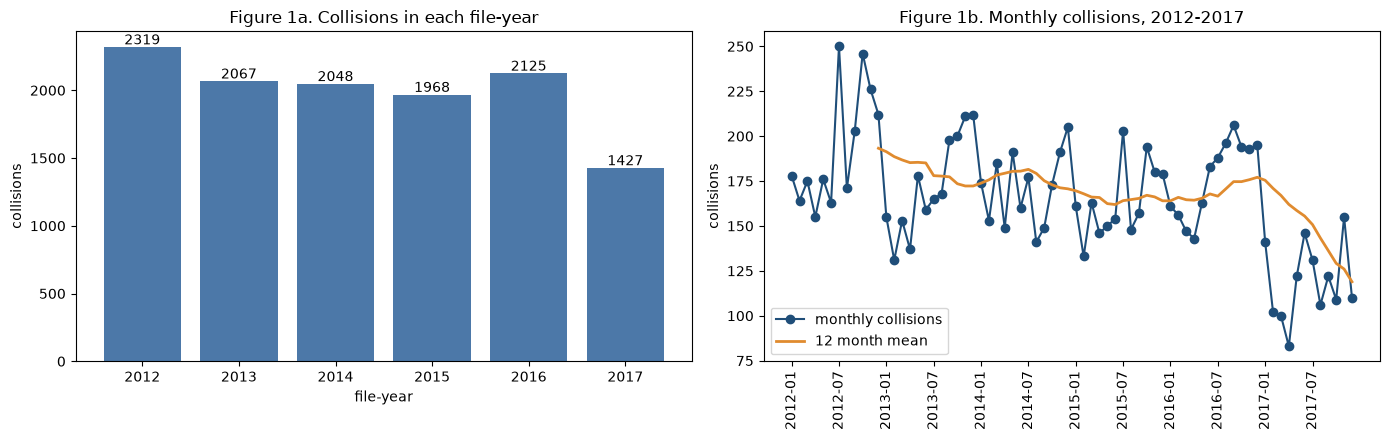

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].bar(yearly.index.astype(str), yearly.values, color='#4c78a8')
for i in range(len(yearly)):
    axes[0].text(i, yearly.values[i] + 20, str(yearly.values[i]), ha='center')
axes[0].set_title('Figure 1a. Collisions in each file-year')
axes[0].set_xlabel('file-year')
axes[0].set_ylabel('collisions')
axes[1].plot(monthly.index, monthly.values, marker='o', color='#1f4e79', label='monthly collisions')
axes[1].plot(monthly.index, monthly.rolling(12).mean(), color='#e08b2f', linewidth=2, label='12 month mean')
ticks = list(range(0, len(monthly), 6))
axes[1].set_xticks(ticks)
axes[1].set_xticklabels([monthly.index[i] for i in ticks], rotation=90)
axes[1].set_title('Figure 1b. Monthly collisions, 2012-2017')
axes[1].set_ylabel('collisions')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.savefig(FIG + '/figure_01_coverage_and_monthly_collisions.png', bbox_inches='tight')
plt.show()

In [11]:
surface_counts = pd.crosstab(collisions['Surface'], collisions['Severity'])[SEVERITY_ORDER]
surface_counts['N'] = surface_counts.sum(axis=1)
surface_percent = surface_counts[SEVERITY_ORDER].div(surface_counts['N'], axis=0) * 100
weather_counts = pd.crosstab(collisions['Weather'], collisions['Severity'])[SEVERITY_ORDER]
weather_counts['N'] = weather_counts.sum(axis=1)
weather_percent = weather_counts[SEVERITY_ORDER].div(weather_counts['N'], axis=0) * 100
surface_counts.to_csv(CLEAN + '/table_severity_by_road_surface.csv')
weather_counts.to_csv(CLEAN + '/table_severity_by_weather.csv')
surface_counts

Severity,Fatal,Serious,Slight,N
Surface,,,,
Dry,137,1284,6766,8187
Flood (over 3cm),0,0,7,7
Frost or ice,1,23,160,184
Snow,0,5,28,33
Unknown or not stated,0,2,15,17
Wet or damp,51,536,2939,3526


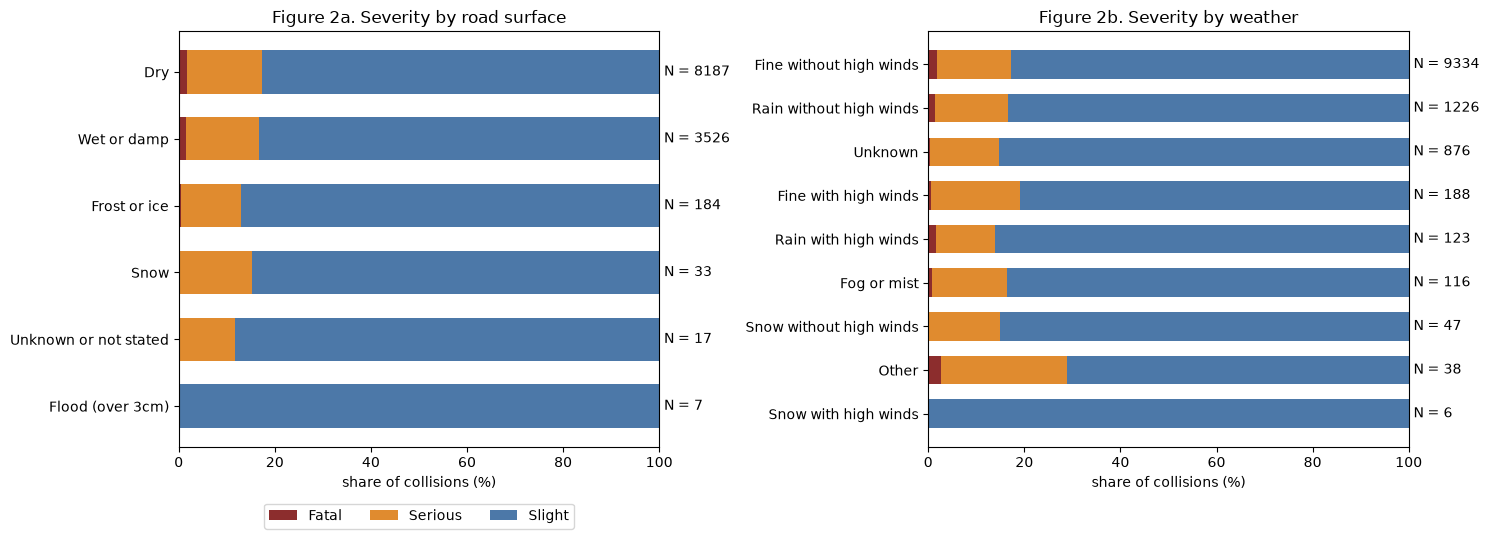

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, counts, percent, title in [[axes[0], surface_counts, surface_percent, 'Figure 2a. Severity by road surface'],
                                   [axes[1], weather_counts, weather_percent, 'Figure 2b. Severity by weather']]:
    groups = counts.sort_values('N').index
    left = np.zeros(len(groups))
    for severity in SEVERITY_ORDER:
        ax.barh(groups, percent.loc[groups, severity].values, left=left, height=0.65,
                color=SEVERITY_COLOURS[severity], label=severity)
        left = left + percent.loc[groups, severity].values
    for i in range(len(groups)):
        ax.text(101, i, 'N = ' + str(counts.loc[groups[i], 'N']), va='center')
    ax.set_xlim(0, 100)
    ax.set_xlabel('share of collisions (%)')
    ax.set_title(title)
    ax.grid(axis='y', visible=False)
axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3)
plt.tight_layout()
plt.savefig(FIG + '/figure_02_severity_by_surface_and_weather.png', bbox_inches='tight')
plt.show()

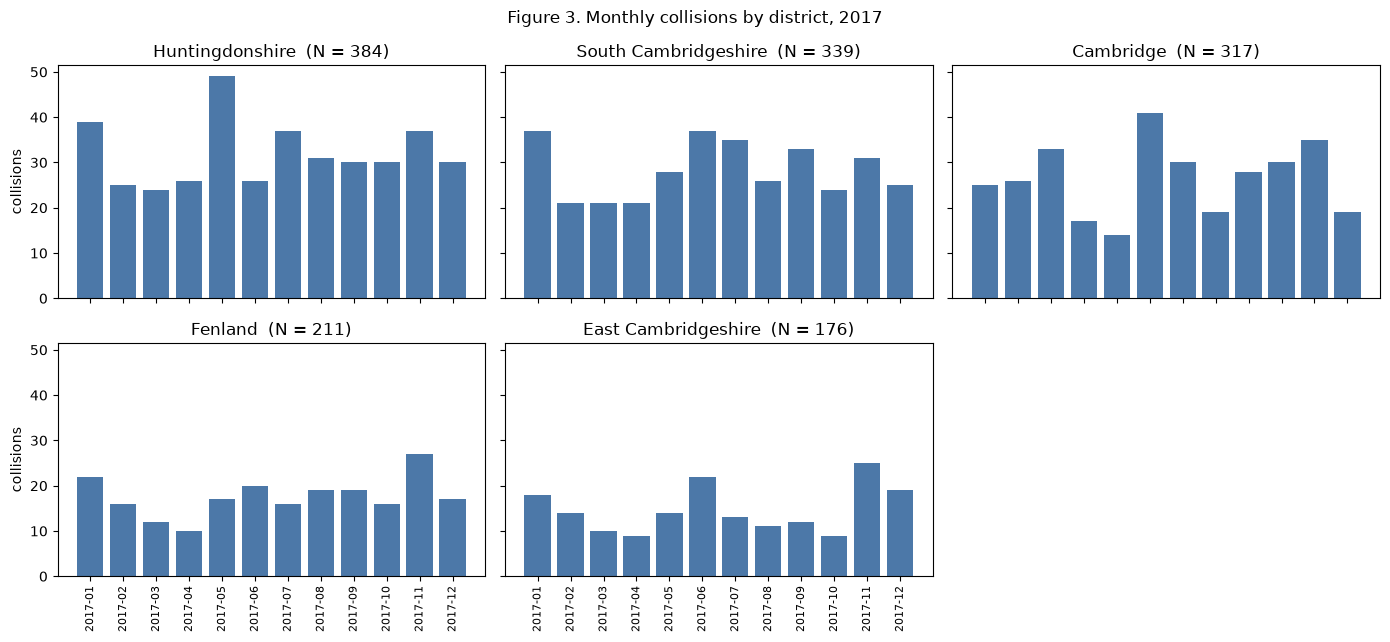

District
Cambridge               317
East Cambridgeshire     176
Fenland                 211
Huntingdonshire         384
South Cambridgeshire    339
dtype: int64

In [13]:
district_2017 = collisions[collisions['Year'] == 2017]
district_month = pd.crosstab(district_2017['Month'], district_2017['District'])
district_totals = district_month.sum()
district_month.to_csv(CLEAN + '/table_monthly_collisions_by_district_2017.csv')
districts = list(district_totals.sort_values(ascending=False).index)
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5), sharex=True, sharey=True)
for i in range(len(districts)):
    ax = axes[i // 3, i % 3]
    ax.bar(district_month.index, district_month[districts[i]], color='#4c78a8')
    ax.set_title(districts[i] + '  (N = ' + str(district_totals[districts[i]]) + ')')
    ax.tick_params(axis='x', labelrotation=90, labelsize=8)
for i in range(len(districts), 6):
    axes[i // 3, i % 3].axis('off')
axes[0, 0].set_ylabel('collisions')
axes[1, 0].set_ylabel('collisions')
plt.suptitle('Figure 3. Monthly collisions by district, 2017')
plt.tight_layout()
plt.savefig(FIG + '/figure_03_district_small_multiples_2017.png', bbox_inches='tight')
plt.show()
district_totals

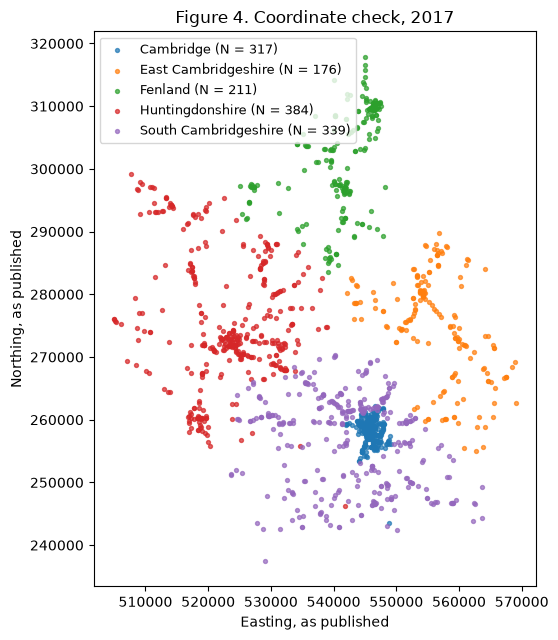

records with coordinates: 11954 of 11954


In [14]:
coords = collisions.dropna(subset=['Easting', 'Northing'])
plt.figure(figsize=(9, 6.5))
for district in sorted(district_2017['District'].unique()):
    part = district_2017[district_2017['District'] == district]
    plt.scatter(part['Easting'], part['Northing'], s=8, alpha=0.7,
                label=district + ' (N = ' + str(len(part)) + ')')
plt.gca().set_aspect('equal')
plt.xlabel('Easting, as published')
plt.ylabel('Northing, as published')
plt.title('Figure 4. Coordinate check, 2017')
plt.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(FIG + '/figure_04_coordinate_check_2017.png', bbox_inches='tight')
plt.show()
print('records with coordinates:', len(coords), 'of', len(collisions))

## Step 5. Supplementary analysis of Dataset 1 (Task 5)

In [15]:
rows = []
for area in mode_data:
    data = mode_data[area]
    for i in range(len(data)):
        for month in months:
            rows.append({'Area': area, 'Mode': data['Mode'][i], 'Month': month,
                         'State': state(data[month][i])})
mode_long = pd.DataFrame(rows)
mode_long.to_csv(CLEAN + '/clean_transport_mode_states_long.csv', index=False)
state_counts = pd.crosstab(mode_long['Area'], mode_long['State']).reindex(columns=STATE_ORDER, fill_value=0)
state_share = state_counts.div(state_counts.sum(axis=1), axis=0) * 100
state_counts.to_csv(CLEAN + '/table_mode_states_by_area.csv')
print('cells:', len(mode_long), '| suppressed:', (mode_long['State'] == '<5').sum())
state_counts

cells: 2448 | suppressed: 795


State,5 or more,1 to 4,0,<5,-1,blank
Area,,,,,,
Cambridge City,272,0,1,133,0,2
Cambridgeshire,405,0,0,3,0,0
East Cambridgeshire,165,0,59,183,1,0
Fenland,184,0,24,200,0,0
Huntingdonshire,258,0,12,138,0,0
South Cambridgeshire,256,0,14,138,0,0


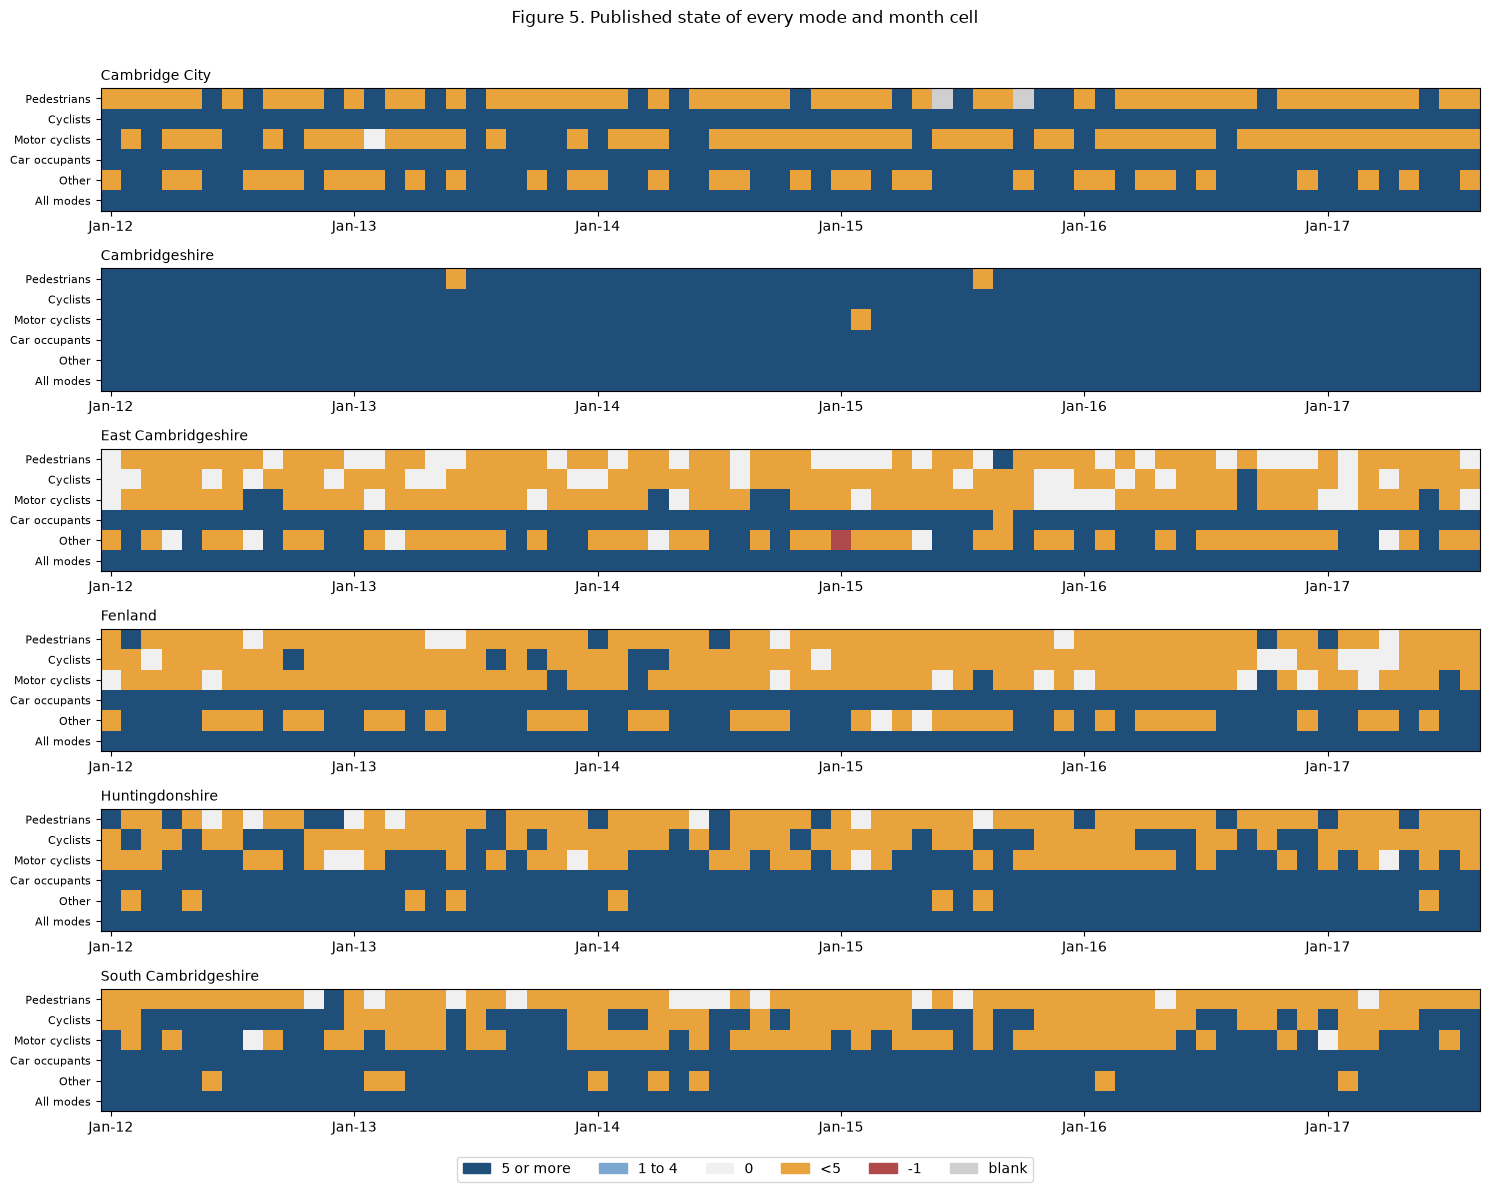

In [16]:
state_number = {}
for i in range(len(STATE_ORDER)):
    state_number[STATE_ORDER[i]] = i
colour_map = ListedColormap([STATE_COLOURS[s] for s in STATE_ORDER])
areas = list(state_counts.index)
modes = list(mode_data['Cambridgeshire']['Mode'])
fig, axes = plt.subplots(len(areas), 1, figsize=(15, 12))
for i in range(len(areas)):
    grid = np.zeros((len(modes), len(months)))
    for row in range(len(modes)):
        for col in range(len(months)):
            grid[row, col] = state_number[state(mode_data[areas[i]][months[col]][row])]
    axes[i].imshow(grid, aspect='auto', cmap=colour_map, vmin=0, vmax=len(STATE_ORDER) - 1)
    axes[i].set_yticks(range(len(modes)))
    axes[i].set_yticklabels(modes, fontsize=8)
    year_ticks = [j for j in range(len(months)) if months[j].startswith('Jan')]
    axes[i].set_xticks(year_ticks)
    axes[i].set_xticklabels([months[j] for j in year_ticks])
    axes[i].set_title(areas[i], fontsize=10, loc='left')
    axes[i].grid(False)
fig.legend([plt.Rectangle((0, 0), 1, 1, color=STATE_COLOURS[s]) for s in STATE_ORDER], STATE_ORDER,
           loc='lower center', ncol=6)
plt.suptitle('Figure 5. Published state of every mode and month cell')
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(FIG + '/figure_05_disclosure_aware_state_map.png', bbox_inches='tight')
plt.show()

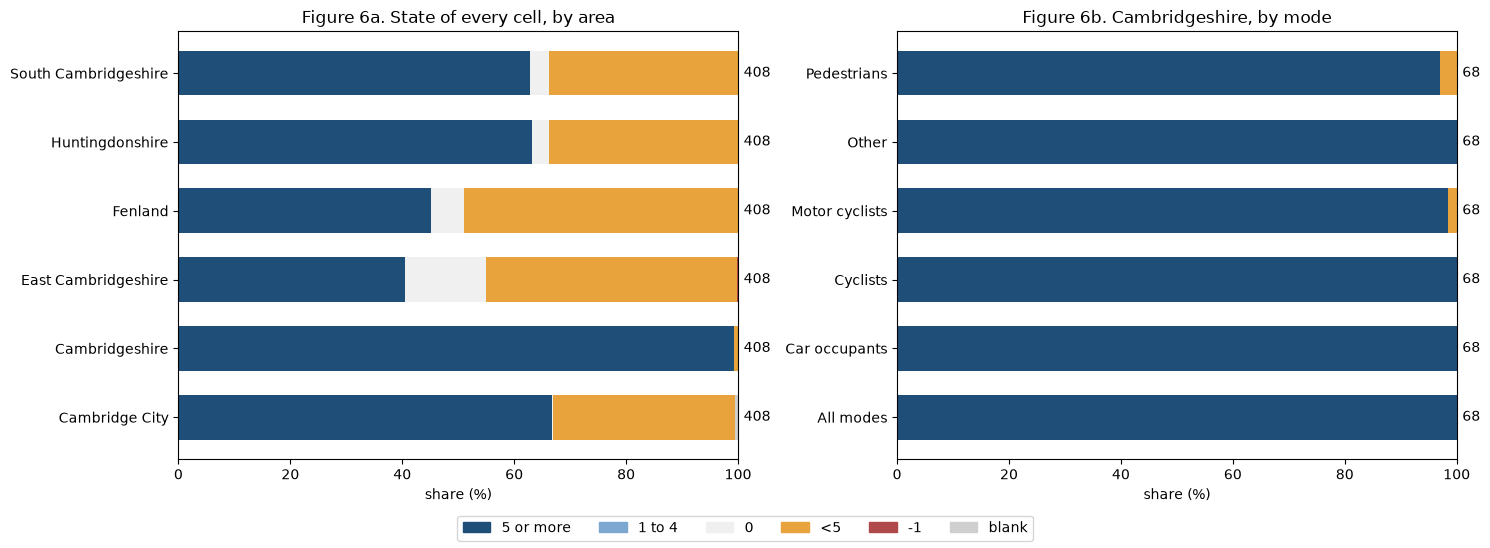

suppressed share: 32.5 %


In [17]:
county_states = pd.crosstab(mode_long[mode_long['Area'] == 'Cambridgeshire']['Mode'],
                            mode_long[mode_long['Area'] == 'Cambridgeshire']['State'])
county_states = county_states.reindex(columns=STATE_ORDER, fill_value=0)
county_share = county_states.div(county_states.sum(axis=1), axis=0) * 100
county_states.to_csv(CLEAN + '/table_mode_states_county_by_mode.csv')
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, share, counts, title in [[axes[0], state_share, state_counts, 'Figure 6a. State of every cell, by area'],
                                 [axes[1], county_share, county_states, 'Figure 6b. Cambridgeshire, by mode']]:
    left = np.zeros(len(share))
    for s in STATE_ORDER:
        ax.barh(share.index, share[s].values, left=left, height=0.65, color=STATE_COLOURS[s], label=s)
        left = left + share[s].values
    for i in range(len(share)):
        ax.text(101, i, str(counts.sum(axis=1).values[i]), va='center')
    ax.set_xlim(0, 100)
    ax.set_xlabel('share (%)')
    ax.set_title(title)
fig.legend([plt.Rectangle((0, 0), 1, 1, color=STATE_COLOURS[s]) for s in STATE_ORDER], STATE_ORDER,
           loc='lower center', ncol=6)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(FIG + '/figure_06_mode_state_composition.png', bbox_inches='tight')
plt.show()
print('suppressed share:', round(100 * (mode_long['State'] == '<5').mean(), 1), '%')

## Step 6. Checks

In [18]:
checks = []
def add(name, ok, detail=''):
    checks.append({'check': name, 'result': 'PASS' if ok else 'FAIL', 'detail': detail})

raw_records = 0
for year in range(2012, 2018):
    raw_records = raw_records + len(read_location(year))
add('monthly counts add up to the raw records', monthly.sum() == raw_records, raw_records)
add('yearly counts add up to the raw records', yearly.sum() == raw_records)
add('severity shares add up to 100 per cent, by surface', np.allclose(surface_percent.sum(axis=1), 100))
add('severity shares add up to 100 per cent, by weather', np.allclose(weather_percent.sum(axis=1), 100))
add('every 2017 record has a district name', district_2017['District'].isna().sum() == 0)
add('district totals add up to the 2017 file', district_totals.sum() == len(district_2017))
add('coordinates are present for every record', len(coords) == len(collisions))
add('all transport mode files use the same months', len(months) == 68 and len(coverage_mode) == 6)
add('suppressed cells are kept as states', (mode_long['State'] == '<5').sum() == coverage_mode['<5'].sum(),
    (mode_long['State'] == '<5').sum())
add('no state outside the agreed list appears', len(set(mode_long['State']) - set(STATE_ORDER)) == 0)
add('the 2017 file has no Peterborough record', 'Peterborough' not in list(district_totals.index))
add('the 2018 file does have Peterborough', 'Peterborough' in list(collisions_2018['District'].unique()))
figures = ['figure_01_coverage_and_monthly_collisions.png', 'figure_02_severity_by_surface_and_weather.png',
           'figure_03_district_small_multiples_2017.png', 'figure_04_coordinate_check_2017.png',
           'figure_05_disclosure_aware_state_map.png', 'figure_06_mode_state_composition.png']
add('all six figures were saved', len([f for f in figures if not os.path.exists(FIG + '/' + f)]) == 0)
checks_table = pd.DataFrame(checks)
checks_table.to_csv(CLEAN + '/validation_checks.csv', index=False)
checks_table

,check,result,detail
0,monthly counts add up to the raw records,PASS,11954
1,yearly counts add up to the raw records,PASS,
2,"severity shares add up to 100 per cent, by sur...",PASS,
3,"severity shares add up to 100 per cent, by wea...",PASS,
4,every 2017 record has a district name,PASS,
5,district totals add up to the 2017 file,PASS,
6,coordinates are present for every record,PASS,
7,all transport mode files use the same months,PASS,
8,suppressed cells are kept as states,PASS,795
9,no state outside the agreed list appears,PASS,


In [19]:
sf_surface = (surface_percent['Fatal'] + surface_percent['Serious']).sort_values()
sf_weather = (weather_percent['Fatal'] + weather_percent['Serious']).sort_values()
slight = round(100 * (collisions['Severity'] == 'Slight').mean(), 1)
serious = round(100 * (collisions['Severity'] == 'Serious').mean(), 1)
fatal = round(100 * (collisions['Severity'] == 'Fatal').mean(), 1)
suppressed = round(100 * (mode_long['State'] == '<5').mean(), 1)
paragraph_one = (
    f'The Cambridgeshire files record {yearly.sum()} collisions between 2012 and 2017. '
    f'{yearly.idxmin()} has the fewest ({yearly.min()}) and {yearly.idxmax()} the most ({yearly.max()}). '
    f'The busiest month is {monthly.idxmax()} with {monthly.max()} collisions and the quietest is '
    f'{monthly.idxmin()} with {monthly.min()}. Figure 1b shows that most of the movement is seasonal. '
    f'Recorded severity is {slight} per cent slight, {serious} per cent serious and {fatal} per cent fatal.')
paragraph_two = (
    f'Figure 2 compares severity across road surface and weather and every bar shows its sample size. '
    f'The largest share of serious and fatal outcomes is in the {sf_surface.index[-1]} group '
    f'({round(sf_surface.values[-1], 1)} per cent of {surface_counts.loc[sf_surface.index[-1], "N"]} collisions) '
    f'and the smallest in {sf_surface.index[0]}. Figure 3 compares the five districts for 2017: '
    f'{district_totals.idxmax()} has the most collisions ({district_totals.max()}) and {district_totals.idxmin()} '
    f'the fewest ({district_totals.min()}). In Dataset 1, {suppressed} per cent of the {len(mode_long)} mode and '
    f'month cells are suppressed, so Figure 5 shows the state of each cell instead of a total.')
print(paragraph_one)
print()
print(paragraph_two)

The Cambridgeshire files record 11954 collisions between 2012 and 2017. 2017 has the fewest (1427) and 2012 the most (2319). The busiest month is 2012-07 with 250 collisions and the quietest is 2017-04 with 83. Figure 1b shows that most of the movement is seasonal. Recorded severity is 82.9 per cent slight, 15.5 per cent serious and 1.6 per cent fatal.

Figure 2 compares severity across road surface and weather and every bar shows its sample size. The largest share of serious and fatal outcomes is in the Dry group (17.4 per cent of 8187 collisions) and the smallest in Flood (over 3cm). Figure 3 compares the five districts for 2017: Huntingdonshire has the most collisions (384) and East Cambridgeshire the fewest (176). In Dataset 1, 32.5 per cent of the 2448 mode and month cells are suppressed, so Figure 5 shows the state of each cell instead of a total.


## Limits and deliverables

1. The 2012-2016 files publish no district code and no casualty count, so Figure 3 and the casualty
   total cover 2017 only.
2. The 2017 file covers the five Cambridgeshire districts; the 2018 file also contains Peterborough
   (E06000031) and the transport mode files cover Cambridgeshire and its districts only, so
   Peterborough is reported separately.
3. The transport mode files end in August 2017 and no value is extrapolated after that month.
4. Cells published as `<5`, the `-1` code and blanks keep their own state; no total is built from
   censored cells.
5. The files state no coordinate reference system, so the coordinates are plotted as published and no
   base map is drawn.

| Deliverable | File |
| --- | --- |
| source log and raw file inventory | `data/clean/source_log.csv` |
| data dictionary and coverage audit | `data/clean/data_dictionary.csv`, `coverage_audit_*.csv` |
| clean tables and cleaning log | `data/clean/clean_*.csv`, `cleaning_log.csv` |
| validated summary tables | `data/clean/table_*.csv` |
| disclosure-aware mode summary | Figures 5 and 6 |
| visual storyboard | `figures/figure_01` to `figure_06` |
| checks | `data/clean/validation_checks.csv` |